# 💎 Prédiction du Prix des Diamants
## Notebook 2 : Prétraitement, Modélisation & Évaluation
**Auteur :** Hadj Mbarek Arwa  
**Date :** Avril 2026

---
### Objectif de ce notebook
1. **Nettoyer et préparer** les données
2. **Tester** avec et **sans** transformation logarithmique de la cible (price)
3. **Entraîner** 4 modèles × 2 approches → **métriques toujours converties en $**
4. **Sélectionner** la meilleure combinaison (modèle + approche)
5. **Optimiser** avec GridSearchCV
6. **Interpréter** les résultats

## Étape 0 — Importation des librairies

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

print('Toutes les librairies importées avec succès !')

Toutes les librairies importées avec succès !


## Étape 1 — Chargement des données

In [16]:
# ── Option 1 : fichier local (votre chemin) ─────────────────────────────────
df = pd.read_csv(r'C:\Users\TUF\Downloads\diamond_project\diamond_project\data\diamonds.csv')

# Supprimer colonne index si présente
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])



print(f'Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head(3)

Dataset chargé : 53,940 lignes × 10 colonnes


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31


## Étape 2 — Nettoyage des données

In [17]:
print(f'Taille avant nettoyage : {df.shape[0]:,} lignes')


# Supprimer dimensions impossibles (= 0)
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
print(f'Après suppression dim=0   : {df.shape[0]:,} lignes')

# Supprimer valeurs aberrantes extrêmes
df = df[(df['y'] < 20) & (df['z'] < 20)]
print(f'Après suppression outliers : {df.shape[0]:,} lignes')

# Supprimer les doublons
nb_doublons = df.duplicated().sum()
df = df.drop_duplicates()
print(f'Après suppression doublons : {df.shape[0]:,} lignes ({nb_doublons} doublons supprimés)')

print('\n Nettoyage terminé !')

Taille avant nettoyage : 53,940 lignes
Après suppression dim=0   : 53,920 lignes
Après suppression outliers : 53,917 lignes
Après suppression doublons : 53,772 lignes (145 doublons supprimés)

 Nettoyage terminé !


## Étape 3 — Feature Engineering

In [18]:
df['volume'] = df['x'] * df['y'] * df['z']
df['carat_per_volume'] = df['carat'] / (df['volume'] + 1e-6)

print('Nouvelles features créées :')
print(f"   → 'volume'           : exemple = {df['volume'].iloc[0]:.2f} mm³")
print(f"   → 'carat_per_volume' : exemple = {df['carat_per_volume'].iloc[0]:.4f}")
print(f"\n   Dataset final : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

Nouvelles features créées :
   → 'volume'           : exemple = 38.20 mm³
   → 'carat_per_volume' : exemple = 0.0060

   Dataset final : 53,772 lignes × 12 colonnes


## Étape 4 — Encodage des Variables Catégorielles

In [19]:
cut_mapping     = {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
color_mapping   = {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
clarity_mapping = {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}

df['cut_encoded']     = df['cut'].map(cut_mapping)
df['color_encoded']   = df['color'].map(color_mapping)
df['clarity_encoded'] = df['clarity'].map(clarity_mapping)
df = df.drop(columns=['cut', 'color', 'clarity'])

print('Encodage ordinal appliqué :')
print(f'   cut_mapping     : {cut_mapping}')
print(f'   color_mapping   : {color_mapping}')
print(f'   clarity_mapping : {clarity_mapping}')
df.head(3)

Encodage ordinal appliqué :
   cut_mapping     : {'Fair': 1, 'Good': 2, 'Very Good': 3, 'Premium': 4, 'Ideal': 5}
   color_mapping   : {'J': 1, 'I': 2, 'H': 3, 'G': 4, 'F': 5, 'E': 6, 'D': 7}
   clarity_mapping : {'I1': 1, 'SI2': 2, 'SI1': 3, 'VS2': 4, 'VS1': 5, 'VVS2': 6, 'VVS1': 7, 'IF': 8}


,carat,depth,table,price,x,y,z,volume,carat_per_volume,cut_encoded,color_encoded,clarity_encoded
0,0.23,61.5,55.0,326,3.95,3.98,2.43,38.202030,0.006021,5,6,2
1,0.21,59.8,61.0,326,3.89,3.84,2.31,34.505856,0.006086,4,6,3
2,0.23,56.9,65.0,327,4.05,4.07,2.31,38.076885,0.006040,2,6,5


## Étape 5 — Séparation Features / Cible et Train/Test Split

In [20]:
X = df.drop(columns=['price'])
y = df['price']

print(f'Features (X) : {list(X.columns)}')
print(f'Cible (y)    : price')
print(f'Prix min : ${y.min():,}  |  max : ${y.max():,}  |  médiane : ${y.median():,.0f}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'\nDonnées divisées :')
print(f'   X_train : {X_train.shape[0]:,} lignes (80%)')
print(f'   X_test  : {X_test.shape[0]:,} lignes  (20%)')

Features (X) : ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume', 'carat_per_volume', 'cut_encoded', 'color_encoded', 'clarity_encoded']
Cible (y)    : price
Prix min : $326  |  max : $18,823  |  médiane : $2,401

Données divisées :
   X_train : 43,017 lignes (80%)
   X_test  : 10,755 lignes  (20%)


## Étape 6 — Normalisation (StandardScaler)

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(' Normalisation appliquée (uniquement sur X — pour la Régression Linéaire)')
print(f'   Moyenne (≈ 0)    : {X_train_scaled.mean(axis=0).round(3)}')
print(f'   Écart-type (≈ 1) : {X_train_scaled.std(axis=0).round(3)}')

 Normalisation appliquée (uniquement sur X — pour la Régression Linéaire)
   Moyenne (≈ 0)    : [ 0. -0.  0. -0.  0.  0. -0. -0. -0.  0.  0.]
   Écart-type (≈ 1) : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Étape 7 — Comparaison : avec et sans log(price)

### Pourquoi tester log(price) ?
La distribution du prix des diamants est **asymétrique à droite** (skewed).
Appliquer `log(price)` peut :
- Rendre la distribution plus symétrique → aide la régression linéaire
- Réduire l'influence des prix très élevés
- Parfois améliorer les performances des modèles d'ensemble

###  Métriques toujours en $ (même échelle)
- **Sans log** : prédictions directement en $
- **Avec log** : on prédit `log(price)`, puis on applique `exp()` pour revenir en $
- → Comparaison équitable sur RMSE et MAE en $

In [22]:
def evaluer_modele(modele, X_tr, X_te, y_tr, y_te, nom, log_target=False):
    """
    Entraîne un modèle et retourne ses métriques EN $ (même échelle).

    Paramètres:
    -----------
    log_target : bool
        Si True  → entraîne sur log(price), prédit log(price), applique exp()
                   pour obtenir des métriques en $ comparables à log_target=False.
        Si False → entraîne directement sur price en $.
    """
    y_tr_orig = y_tr.values if hasattr(y_tr, 'values') else np.array(y_tr)
    y_te_orig = y_te.values if hasattr(y_te, 'values') else np.array(y_te)

    # ── Transformer la cible si log ──────────────────────────────────────────
    if log_target:
        y_tr_fit = np.log(y_tr_orig)   # log(price) pour l'entraînement
    else:
        y_tr_fit = y_tr_orig           # price en $ directement

    # ── Entraînement ──────────────────────────────────────────────────────────
    modele.fit(X_tr, y_tr_fit)

    # ── Prédictions ───────────────────────────────────────────────────────────
    y_pred_train_raw = modele.predict(X_tr)
    y_pred_test_raw  = modele.predict(X_te)

    # ── Transformation inverse → prédictions en $ ────────────────────────────
    if log_target:
        y_pred_train = np.exp(y_pred_train_raw)  # exp(log(price)) = price
        y_pred_test  = np.exp(y_pred_test_raw)
    else:
        y_pred_train = y_pred_train_raw
        y_pred_test  = y_pred_test_raw

    # ──  Toutes les métriques sont en $ (même échelle) ─────────────────────
    rmse_train = np.sqrt(mean_squared_error(y_tr_orig, y_pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_te_orig, y_pred_test))
    mae_test   = mean_absolute_error(y_te_orig, y_pred_test)
    r2_train   = r2_score(y_tr_orig, y_pred_train)
    r2_test    = r2_score(y_te_orig, y_pred_test)

    tag = "(log)" if log_target else "(no log)"
    print(f'\n {nom} {tag}')
    print(f'     RMSE  train : ${rmse_train:,.0f}  |  test : ${rmse_test:,.0f}')
    print(f'     MAE   test  : ${mae_test:,.0f}')
    print(f'     R²    train : {r2_train:.4f}  |  test : {r2_test:.4f}')



    return {
        'Modèle':       nom,
        'Log Target':   log_target,
        'RMSE Train ($)': rmse_train,
        'RMSE Test ($)':  rmse_test,
        'MAE Test ($)':   mae_test,
        'R² Train':     r2_train,
        'R² Test':      r2_test,
        'y_pred':       y_pred_test,
        'modele_fit':   modele
    }

print(' Fonction evaluer_modele() prête.')

 Fonction evaluer_modele() prête.


### Étape 7A — Entraînement SANS transformation log
*(cible = price en \$)*

In [23]:
print('=' * 65)
print(' APPROCHE 1 : Sans log  —  cible = price [$]')
print('=' * 65)

resultats = []

# ── Modèle 1 : Régression Linéaire (X scalé) ─────────────────────────────
lr = LinearRegression()
res = evaluer_modele(lr, X_train_scaled, X_test_scaled, y_train, y_test,
                     'Régression Linéaire', log_target=False)
resultats.append(res)

# ── Modèle 2 : Arbre de Décision ─────────────────────────────────────────
dt = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)
res = evaluer_modele(dt, X_train, X_test, y_train, y_test,
                     'Arbre de Décision', log_target=False)
resultats.append(res)

# ── Modèle 3 : Random Forest ─────────────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
res = evaluer_modele(rf, X_train, X_test, y_train, y_test,
                     'Random Forest', log_target=False)
resultats.append(res)

# ── Modèle 4 : XGBoost ───────────────────────────────────────────────────
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                   random_state=RANDOM_STATE, verbosity=0)
res = evaluer_modele(xgb, X_train, X_test, y_train, y_test,
                     'XGBoost', log_target=False)
resultats.append(res)

print('\n' + '=' * 65)
print(' Entraînement SANS log terminé !')

 APPROCHE 1 : Sans log  —  cible = price [$]

 Régression Linéaire (no log)
     RMSE  train : $1,191  |  test : $1,199
     MAE   test  : $781
     R²    train : 0.9112  |  test : 0.9075

 Arbre de Décision (no log)
     RMSE  train : $527  |  test : $629
     MAE   test  : $336
     R²    train : 0.9826  |  test : 0.9745

 Random Forest (no log)
     RMSE  train : $204  |  test : $525
     MAE   test  : $263
     R²    train : 0.9974  |  test : 0.9822

 XGBoost (no log)
     RMSE  train : $400  |  test : $525
     MAE   test  : $271
     R²    train : 0.9900  |  test : 0.9822

 Entraînement SANS log terminé !


### Étape 7B — Entraînement AVEC transformation log
*(cible = log(price) pendant l'entraînement ; métriques converties en \$ via exp)*

In [24]:
print('=' * 65)
print(' APPROCHE 2 : Avec log  —  cible = log(price) → exp() → [$]')
print('    Métriques converties en $ pour comparaison équitable')
print('=' * 65)

# ── Modèle 1 : Régression Linéaire (X scalé) ─────────────────────────────
lr_log = LinearRegression()
res = evaluer_modele(lr_log, X_train_scaled, X_test_scaled, y_train, y_test,
                     'Régression Linéaire', log_target=True)
resultats.append(res)

# ── Modèle 2 : Arbre de Décision ─────────────────────────────────────────
dt_log = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)
res = evaluer_modele(dt_log, X_train, X_test, y_train, y_test,
                     'Arbre de Décision', log_target=True)
resultats.append(res)

# ── Modèle 3 : Random Forest ─────────────────────────────────────────────
rf_log = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
res = evaluer_modele(rf_log, X_train, X_test, y_train, y_test,
                     'Random Forest', log_target=True)
resultats.append(res)

# ── Modèle 4 : XGBoost ───────────────────────────────────────────────────
xgb_log = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6,
                       random_state=RANDOM_STATE, verbosity=0)
res = evaluer_modele(xgb_log, X_train, X_test, y_train, y_test,
                     'XGBoost', log_target=True)
resultats.append(res)

print('\n' + '=' * 65)
print(' Entraînement AVEC log terminé !')

 APPROCHE 2 : Avec log  —  cible = log(price) → exp() → [$]
    Métriques converties en $ pour comparaison équitable

 Régression Linéaire (log)
     RMSE  train : $843  |  test : $827
     MAE   test  : $437
     R²    train : 0.9555  |  test : 0.9560

 Arbre de Décision (log)
     RMSE  train : $579  |  test : $631
     MAE   test  : $338
     R²    train : 0.9790  |  test : 0.9744

 Random Forest (log)
     RMSE  train : $205  |  test : $526
     MAE   test  : $263
     R²    train : 0.9974  |  test : 0.9822

 XGBoost (log)
     RMSE  train : $452  |  test : $528
     MAE   test  : $268
     R²    train : 0.9872  |  test : 0.9821

 Entraînement AVEC log terminé !


## Étape 8 — Tableau de Comparaison (toutes métriques en $)

In [25]:
# ── Construction du tableau de comparaison ───────────────────────────────
df_comp = pd.DataFrame([{
    'Modèle':       r['Modèle'],
    'Approche':     'log(price)' if r['Log Target'] else 'price [$]',
    'RMSE Test ($)':  round(r['RMSE Test ($)']),
    'MAE Test ($)':   round(r['MAE Test ($)']),
    'R² Test':      round(r['R² Test'], 4),
    'R² Train':     round(r['R² Train'], 4),
    'Log Target':   r['Log Target']
} for r in resultats])

df_comp = df_comp.sort_values('RMSE Test ($)', ascending=True).reset_index(drop=True)

print('\n══════════ Tableau de Comparaison ══════════')
print('  Toutes les métriques sont en $ (même échelle)')
print('  log(price) → exp(prédiction) pour revenir en $')
print('══════════════════════════════════════════════')
print(df_comp[['Modèle','Approche','RMSE Test ($)','MAE Test ($)','R² Test']].to_string(index=False))

winner_row = df_comp.iloc[0]
print(f'\n MEILLEURE COMBINAISON :')
print(f"   Modèle   : {winner_row['Modèle']}")
print(f"   Approche : {winner_row['Approche']}")
print(f"   RMSE test: ${winner_row['RMSE Test ($)']:,}")
print(f"   MAE test : ${winner_row['MAE Test ($)']:,}")
print(f"   R² test  : {winner_row['R² Test']}")


══════════ Tableau de Comparaison ══════════
  Toutes les métriques sont en $ (même échelle)
  log(price) → exp(prédiction) pour revenir en $
══════════════════════════════════════════════
             Modèle   Approche  RMSE Test ($)  MAE Test ($)  R² Test
      Random Forest  price [$]            525           263   0.9822
            XGBoost  price [$]            525           271   0.9822
      Random Forest log(price)            526           263   0.9822
            XGBoost log(price)            528           268   0.9821
  Arbre de Décision  price [$]            629           336   0.9745
  Arbre de Décision log(price)            631           338   0.9744
Régression Linéaire log(price)            827           437   0.9560
Régression Linéaire  price [$]           1199           781   0.9075

 MEILLEURE COMBINAISON :
   Modèle   : Random Forest
   Approche : price [$]
   RMSE test: $525
   MAE test : $263
   R² test  : 0.9822


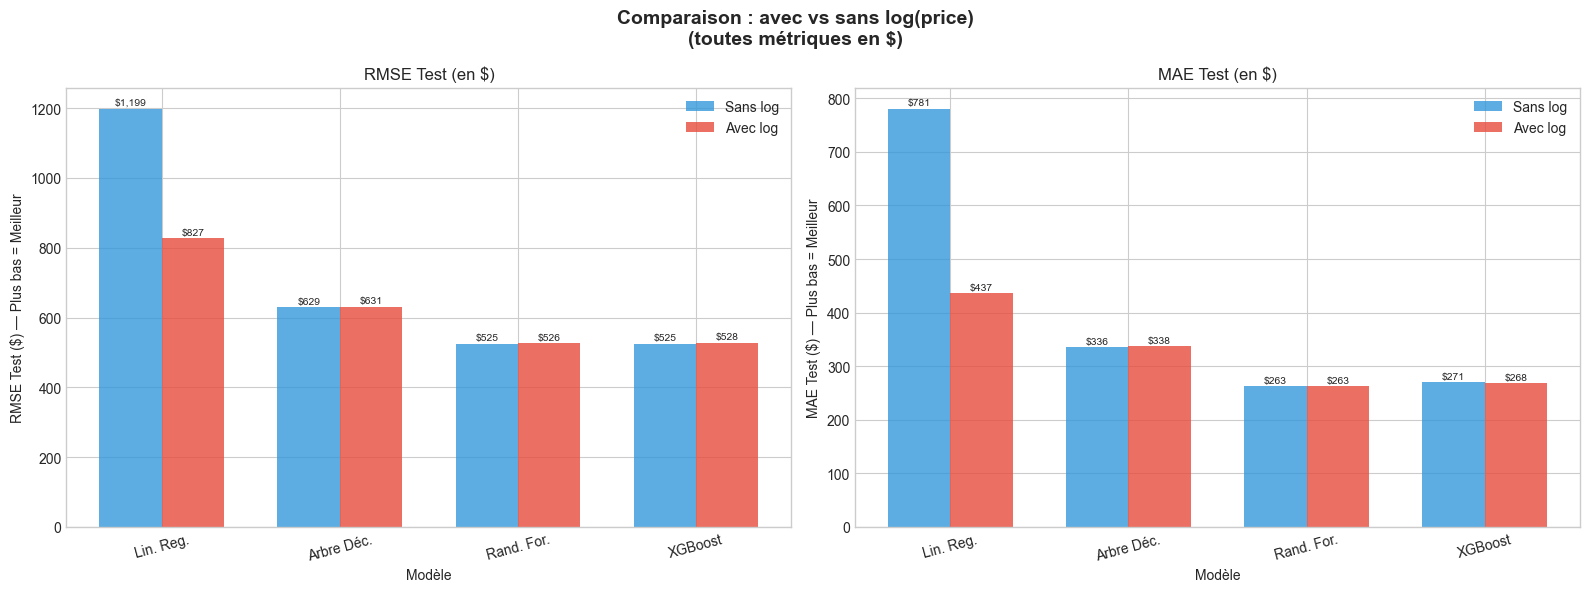


 Conclusion:
   Bleu  = Sans log  (cible = price)
   Rouge = Avec log  (cible = log(price) → exp → $)
   → Les deux approches sont comparées sur la même échelle en $


In [26]:
# ── Visualisation : RMSE test pour toutes les combinaisons ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparaison : avec vs sans log(price)\n(toutes métriques en $)',
             fontsize=14, fontweight='bold')

df_nolog = df_comp[df_comp['Log Target'] == False]
df_log   = df_comp[df_comp['Log Target'] == True]

colors_nolog = ['#3498db'] * len(df_nolog)
colors_log   = ['#e74c3c'] * len(df_log)

# ── Graphique 1 : RMSE Test ───────────────────────────────────────────────
noms_nolog = [f"{r['Modèle']}" for _, r in df_nolog.iterrows()]
noms_log   = [f"{r['Modèle']}" for _, r in df_log.iterrows()]

x = np.arange(4)
width = 0.35

model_order = ['Régression Linéaire', 'Arbre de Décision', 'Random Forest', 'XGBoost']

rmse_nolog = [df_comp[(df_comp['Modèle'] == m) & (df_comp['Log Target'] == False)]['RMSE Test ($)'].values[0]
             for m in model_order]
rmse_log   = [df_comp[(df_comp['Modèle'] == m) & (df_comp['Log Target'] == True)]['RMSE Test ($)'].values[0]
             for m in model_order]

bars1 = axes[0].bar(x - width/2, rmse_nolog, width, label='Sans log', color='#3498db', alpha=0.8)
bars2 = axes[0].bar(x + width/2, rmse_log,   width, label='Avec log',  color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Modèle')
axes[0].set_ylabel('RMSE Test ($) — Plus bas = Meilleur')
axes[0].set_title('RMSE Test (en $)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Lin. Reg.', 'Arbre Déc.', 'Rand. For.', 'XGBoost'], rotation=15)
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'${int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7.5)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'${int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7.5)

# ── Graphique 2 : MAE Test ────────────────────────────────────────────────
mae_nolog = [df_comp[(df_comp['Modèle'] == m) & (df_comp['Log Target'] == False)]['MAE Test ($)'].values[0]
            for m in model_order]
mae_log   = [df_comp[(df_comp['Modèle'] == m) & (df_comp['Log Target'] == True)]['MAE Test ($)'].values[0]
            for m in model_order]

bars3 = axes[1].bar(x - width/2, mae_nolog, width, label='Sans log', color='#3498db', alpha=0.8)
bars4 = axes[1].bar(x + width/2, mae_log,   width, label='Avec log',  color='#e74c3c', alpha=0.8)
axes[1].set_xlabel('Modèle')
axes[1].set_ylabel('MAE Test ($) — Plus bas = Meilleur')
axes[1].set_title('MAE Test (en $)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Lin. Reg.', 'Arbre Déc.', 'Rand. For.', 'XGBoost'], rotation=15)
axes[1].legend()
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                 f'${int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7.5)
for bar in bars4:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
                 f'${int(bar.get_height()):,}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('../data/comparaison_log_vs_nolog.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Conclusion:')
print('   Bleu  = Sans log  (cible = price)')
print('   Rouge = Avec log  (cible = log(price) → exp → $)')
print('   → Les deux approches sont comparées sur la même échelle en $')

## Étape 9 — Optimisation avec GridSearchCV

**Meilleure combinaison sélectionnée** → GridSearch pour trouver les meilleurs hyperparamètres.

> **Note sur le scoring GridSearch avec log :**
> Si l'approche gagnante utilise `log(price)`, le GridSearch optimise sur log-scale
> (pour sélectionner les meilleurs paramètres). L'évaluation finale sur le test set
> utilise `exp()` pour revenir en $.

In [27]:
# ── Identifier le meilleur modèle et la meilleure approche ──────────────
winner_row  = df_comp.iloc[0]  # Trié par RMSE Test ascending
best_name   = winner_row['Modèle']
use_log     = winner_row['Log Target']

print(f' Meilleur modèle   : {best_name}')
print(f'   Meilleure approche : {"log(price)" if use_log else "price [$]"}')
print(f'   RMSE Test baseline : ${winner_row["RMSE Test ($)"]:,}')

# ── Choisir X selon le modèle ─────────────────────────────────────────────
if best_name == 'Régression Linéaire':
    X_tr_gs = X_train_scaled
    X_te_gs = X_test_scaled
else:
    X_tr_gs = X_train
    X_te_gs = X_test

# ── Transformer y selon l'approche ───────────────────────────────────────
if use_log:
    y_tr_gs = np.log(y_train.values)  # entraîner sur log(price)
else:
    y_tr_gs = y_train.values          # entraîner sur price en $

print(f'\n   X shape : {X_tr_gs.shape}')
print(f'   y shape : {y_tr_gs.shape}  |  y min={y_tr_gs.min():.3f}  y max={y_tr_gs.max():.3f}')

 Meilleur modèle   : Random Forest
   Meilleure approche : price [$]
   RMSE Test baseline : $525

   X shape : (43017, 11)
   y shape : (43017,)  |  y min=326.000  y max=18823.000


In [28]:
print(' Optimisation des hyperparamètres avec GridSearchCV...')
print('   (Cela peut prendre quelques minutes — patience ! ☕)')

# ── Grille de paramètres selon le modèle ─────────────────────────────────
if best_name == 'XGBoost':
    estimator = XGBRegressor(random_state=RANDOM_STATE, verbosity=0)
    param_grid = {
        'n_estimators':  [100, 200, 300],
        'max_depth':     [4, 6, 8],
        'learning_rate': [0.05, 0.1, 0.2],
    }
elif best_name == 'Random Forest':
    estimator = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    param_grid = {
        'n_estimators':  [100, 200, 300],
        'max_depth':     [None, 10, 20],
        'min_samples_leaf': [1, 2, 5],
    }
elif best_name == 'Arbre de Décision':
    estimator = DecisionTreeRegressor(random_state=RANDOM_STATE)
    param_grid = {
        'max_depth':        [5, 10, 15, None],
        'min_samples_leaf': [1, 2, 5],
        'min_samples_split': [2, 5, 10],
    }
else:  # Régression Linéaire
    from sklearn.linear_model import Ridge
    estimator = Ridge()
    param_grid = {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    }

# ── GridSearchCV ─────────────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_tr_gs, y_tr_gs)

print(f'\n GridSearch terminé !')
print(f'   Meilleurs paramètres : {grid_search.best_params_}')
print(f'   Meilleur score CV    : {-grid_search.best_score_:.4f} (échelle log si log_target=True)')

 Optimisation des hyperparamètres avec GridSearchCV...
   (Cela peut prendre quelques minutes — patience ! ☕)
Fitting 3 folds for each of 27 candidates, totalling 81 fits

 GridSearch terminé !
   Meilleurs paramètres : {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 300}
   Meilleur score CV    : 555.5622 (échelle log si log_target=True)


In [29]:
# ── Évaluation finale du meilleur modèle — métriques EN $ ───────────────
best_estimator = grid_search.best_estimator_

y_pred_best_raw = best_estimator.predict(X_te_gs)

#  Transformation inverse pour avoir les prédictions en $
if use_log:
    y_pred_best = np.exp(y_pred_best_raw)
else:
    y_pred_best = y_pred_best_raw

#  Métriques en $
rmse_best = np.sqrt(mean_squared_error(y_test.values, y_pred_best))
mae_best  = mean_absolute_error(y_test.values, y_pred_best)
r2_best   = r2_score(y_test.values, y_pred_best)

approche_str = 'avec log(price)' if use_log else 'sans log'
print(f'\n Performance finale — {best_name} ({approche_str}) optimisé')
print(f'   RMSE Test : ${rmse_best:,.2f}  (erreur quadratique moyenne en $)')
print(f'   MAE  Test : ${mae_best:,.2f}  (erreur absolue moyenne en $)')
print(f'   R²   Test : {r2_best:.4f}  ({r2_best*100:.1f}% de la variance expliquée)')
print(f'\n   Hyperparamètres optimaux : {grid_search.best_params_}')


 Performance finale — Random Forest (sans log) optimisé
   RMSE Test : $522.59  (erreur quadratique moyenne en $)
   MAE  Test : $262.36  (erreur absolue moyenne en $)
   R²   Test : 0.9824  (98.2% de la variance expliquée)

   Hyperparamètres optimaux : {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 300}


## Étape 10 — Analyse des Erreurs

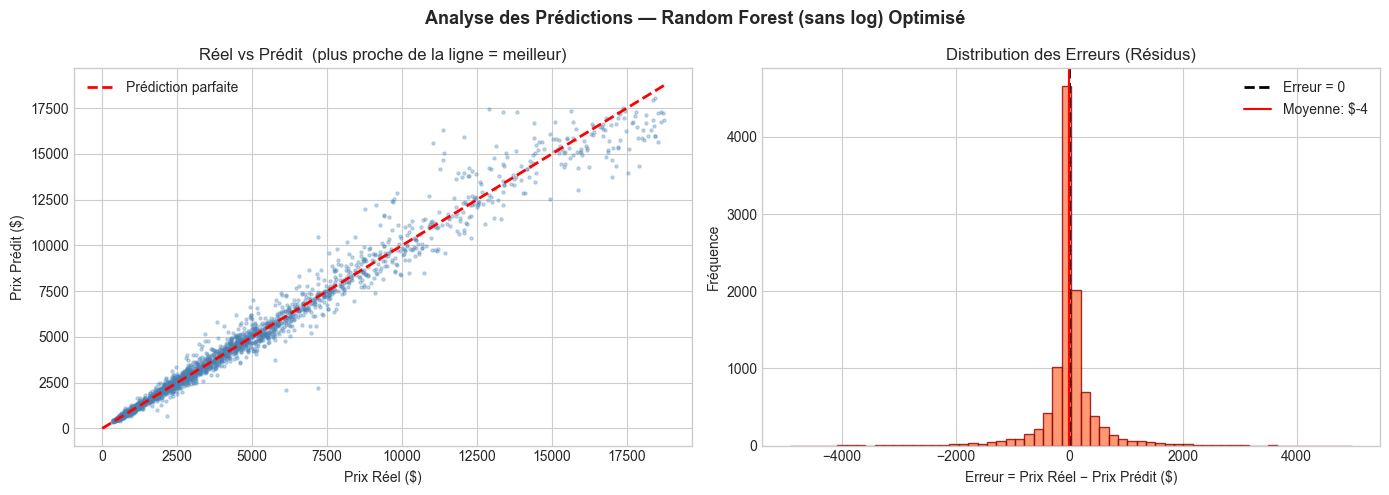

Les résidus sont centrés autour de $-4 → bon signe !


In [30]:
# ── Graphiques : Réel vs Prédit + Distribution des Résidus ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
approche_label = 'avec log' if use_log else 'sans log'
fig.suptitle(f'Analyse des Prédictions — {best_name} ({approche_label}) Optimisé',
             fontsize=13, fontweight='bold')

# Échantillon pour visualisation
sample_idx = np.random.choice(len(y_test), size=min(3000, len(y_test)), replace=False)
y_test_arr = y_test.values

# ── Graphique 1 : Réel vs Prédit ──────────────────────────────────────────
axes[0].scatter(y_test_arr[sample_idx], y_pred_best[sample_idx],
                alpha=0.3, s=5, color='steelblue')
max_val = max(y_test_arr.max(), y_pred_best.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Prix Réel ($)')
axes[0].set_ylabel('Prix Prédit ($)')
axes[0].set_title('Réel vs Prédit  (plus proche de la ligne = meilleur)')
axes[0].legend()

# ── Graphique 2 : Distribution des Résidus ────────────────────────────────
residus = y_test_arr - y_pred_best
axes[1].hist(residus, bins=60, color='coral', edgecolor='darkred', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=2, linestyle='--', label='Erreur = 0')
axes[1].axvline(residus.mean(), color='red', linestyle='-',
                label=f'Moyenne: ${residus.mean():.0f}')
axes[1].set_xlabel('Erreur = Prix Réel − Prix Prédit ($)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des Erreurs (Résidus)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/analyse_erreurs_optimise.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Les résidus sont centrés autour de ${residus.mean():.0f} → bon signe !')

## Étape 11 — Importance des Features

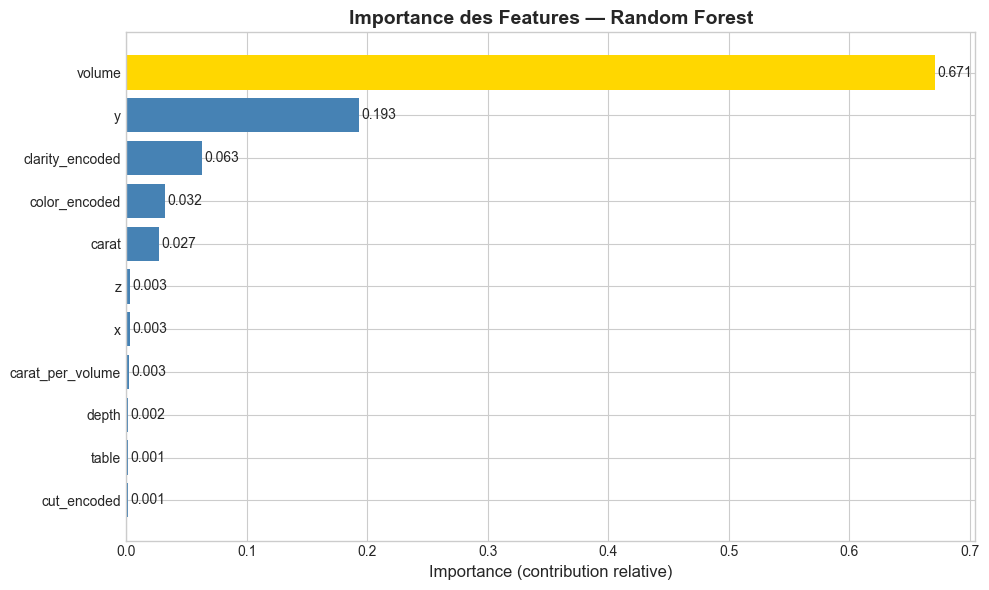

Top 3 features les plus importantes :
   1. volume              : 0.6709 (67.1%)
   2. y                   : 0.1930 (19.3%)
   3. clarity_encoded     : 0.0629 (6.3%)


In [31]:
feature_names = X.columns.tolist()

# Feature importance disponible pour les modèles basés sur des arbres
if hasattr(best_estimator, 'feature_importances_'):
    importances = best_estimator.feature_importances_
    sorted_idx  = np.argsort(importances)[::-1]

    fig, ax = plt.subplots(figsize=(10, 6))

    colors_fi = ['gold' if i == sorted_idx[0] else 'steelblue' for i in range(len(feature_names))]
    colors_fi_sorted = [colors_fi[sorted_idx[i]] for i in range(len(sorted_idx))]

    bars = ax.barh(
        [feature_names[i] for i in sorted_idx[::-1]],
        importances[sorted_idx[::-1]],
        color=colors_fi_sorted[::-1]
    )

    ax.set_xlabel('Importance (contribution relative)', fontsize=12)
    ax.set_title(f'Importance des Features — {best_name}', fontsize=14, fontweight='bold')

    for bar in bars:
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2.,
                f'{bar.get_width():.3f}', va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig('../data/feature_importance_optimise.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Top 3 features les plus importantes :')
    for rank, idx in enumerate(sorted_idx[:3], 1):
        print(f'   {rank}. {feature_names[idx]:20s}: {importances[idx]:.4f} ({importances[idx]*100:.1f}%)')
else:
    print('Feature importance non disponible pour ce type de modèle.')
    print('(Disponible pour : Random Forest, XGBoost, Arbre de Décision)')

## Étape 12 — Validation Croisée (Cross-Validation)

In [32]:
print(' Validation croisée (5-fold) sur le meilleur modèle optimisé...')

# On utilise y_tr_gs (log ou original selon la meilleure approche)
y_cv = np.log(y.values) if use_log else y.values

cv_scores = cross_val_score(
    best_estimator, X_tr_gs, y_tr_gs,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print(f'\nRésultats de la validation croisée (R²) :')
print(f"   (sur {'log(price)' if use_log else 'price en $'})")
for fold, score in enumerate(cv_scores, 1):
    print(f'   Fold {fold}: R² = {score:.4f}')

print(f'\n   Moyenne R² : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'   → Le modèle est stable et performant sur toutes les partitions !')

 Validation croisée (5-fold) sur le meilleur modèle optimisé...

Résultats de la validation croisée (R²) :
   (sur price en $)
   Fold 1: R² = 0.9801
   Fold 2: R² = 0.9816
   Fold 3: R² = 0.9812
   Fold 4: R² = 0.9813
   Fold 5: R² = 0.9819

   Moyenne R² : 0.9812 ± 0.0006
   → Le modèle est stable et performant sur toutes les partitions !


## Étape 13 — Sauvegarde du Modèle

In [33]:
import joblib

# Sauvegarder le meilleur modèle
joblib.dump(best_estimator, 'best_model_optimise.pkl')

# Sauvegarder aussi les infos sur la transformation
model_info = {
    'model_name': best_name,
    'log_target': use_log,
    'best_params': grid_search.best_params_,
    'rmse_test_dollars': rmse_best,
    'mae_test_dollars':  mae_best,
    'r2_test':           r2_best
}
joblib.dump(model_info, 'model_info.pkl')

print(' Modèle sauvegardé !')
print(f"   → best_model_optimise.pkl  ({best_name})")
print(f"   → model_info.pkl           (log_target={use_log})")

print('\n══════════ RÉSUMÉ FINAL ══════════')
print(f'  Modèle       : {best_name}')
print(f'  Approche     : {"log(price)" if use_log else "price [$]"}')
print(f'  Paramètres   : {grid_search.best_params_}')
print(f'  RMSE Test    : ${rmse_best:,.2f}')
print(f'  MAE  Test    : ${mae_best:,.2f}')
print(f'  R²   Test    : {r2_best:.4f} ({r2_best*100:.1f}%)')
print('══════════════════════════════════')

 Modèle sauvegardé !
   → best_model_optimise.pkl  (Random Forest)
   → model_info.pkl           (log_target=False)

══════════ RÉSUMÉ FINAL ══════════
  Modèle       : Random Forest
  Approche     : price [$]
  Paramètres   : {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 300}
  RMSE Test    : $522.59
  MAE  Test    : $262.36
  R²   Test    : 0.9824 (98.2%)
══════════════════════════════════
